# 09 — Gaussian/Laplace uncertainty

The deterministic stages produced a regularised MAP estimate of the
log-local-variance surface.

Stage 9 adds the smallest useful Bayesian layer. It does not run MCMC and it
does not replace the calibrated model.

Near the MAP estimate,

$$
F(u_{\mathrm{MAP}}+\delta)
\approx
F(u_{\mathrm{MAP}})+J_{\mathrm{MAP}}\delta.
$$

The local posterior precision is

$$
H
=
J_{\mathrm{MAP}}^\top W^\top WJ_{\mathrm{MAP}}
+
\lambda R,
$$

and the Laplace covariance is

$$
\Sigma_u=H^{-1}.
$$


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.bayesian.laplace import (
    build_laplace_posterior,
    predictive_price_uncertainty,
    surface_uncertainty_summary,
)
from src.inverse.linearized_inverse import (
    finite_difference_jacobian,
)
from src.inverse.nonlinear_inverse import (
    run_gauss_newton_calibration,
)
from src.inverse.parameterization import (
    local_volatility_from_log_variance,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.regularization.scaling import (
    build_nondimensional_regularization_matrix,
)
from src.surfaces.synthetic_surfaces import (
    smile_surface,
)


## 1. Load the Stage 8 deterministic selection

Stage 8 selected:

- the calibration grid;
- the scaled regularisation convention;
- the global regularisation strength \(\lambda\);
- a deterministic starting surface.

Stage 9 requires that output rather than making a new tuning decision.


In [3]:
stage_08_path = (
    project_root
    / "outputs"
    / "stage_08"
    / "selected_scaled_calibration.npz"
)
quote_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)

if not stage_08_path.exists():
    raise FileNotFoundError(
        "Stage 8 output is missing. Run "
        "08_tuning_and_diagnostics.ipynb first."
    )
if not quote_path.exists():
    raise FileNotFoundError(
        "Synthetic quote data is missing. Run "
        "03_synthetic_data.ipynb first."
    )

stage_08 = np.load(stage_08_path)
synthetic_quotes = pd.read_csv(quote_path)

calibration_T = stage_08[
    "calibration_maturities"
]
calibration_x = stage_08[
    "calibration_x"
]
reference_log_variance = stage_08[
    "reference_log_variance"
]
initial_log_variance = stage_08[
    "estimated_log_variance"
]
selected_lambda = float(
    stage_08["selected_lambda"]
)

print("Selected lambda:", selected_lambda)
print("Surface shape:", initial_log_variance.shape)
print("Number of quotes:", len(synthetic_quotes))


Selected lambda: 3162.2776601683795
Surface shape: (5, 9)
Number of quotes: 78


## 2. Rebuild the exact Stage 8 scaled regulariser

The Bayesian prior must use the same matrix and scaling convention as the
deterministic calibration.

The local prior interpretation is

$$
h=u-u_{\mathrm{ref}}
\sim
N\left(0,(\lambda R)^{-1}\right).
$$

Because quote residuals are already standardised by their noise levels, the
same selected \(\lambda\) is the prior-precision multiplier. No extra
observation-variance factor is inserted.


In [4]:
wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    strength=0.20,
    power=2.0,
    start=0.20,
)

confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    quote_log_moneyness=synthetic_quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=synthetic_quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=0.20,
)

combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

regularization_matrix, _, _, scale_information = (
    build_nondimensional_regularization_matrix(
        maturities=calibration_T,
        log_moneyness=calibration_x,
        alpha_x=0.005,
        alpha_T=0.002,
        beta=1e-4,
        potential=combined_potential,
    )
)

print("Scaled R shape:", regularization_matrix.shape)
print("Unit-square cell area:", scale_information["cell_area"])


Scaled R shape: (45, 45)
Unit-square cell area: 0.03125000000000001


## 3. Refine the deterministic MAP using the scaled objective

Stage 8 selected \(\lambda\) using an inexpensive linearised sweep. Before
forming uncertainty intervals, we refine that selected surface with the full
nonlinear PDE objective.

The uncertainty calculation is then centred at this nonlinear MAP estimate.


In [5]:
map_result = run_gauss_newton_calibration(
    reference_log_variance=reference_log_variance,
    initial_log_variance=initial_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    quote_data=synthetic_quotes,
    regularization_matrix=regularization_matrix,
    regularization_strength=selected_lambda,
    spot=100.0,
    finite_difference_step=1e-3,
    jacobian_scheme="forward",
    number_of_strike_points=151,
    number_of_time_steps=120,
    maximum_iterations=4,
    initial_damping=1e-2,
    maximum_absolute_step=1.0,
    relative_objective_tolerance=1e-4,
    relative_step_tolerance=1e-3,
    verbose=True,
)

map_log_variance = map_result[
    "estimated_log_variance"
]
map_prices = map_result["fitted_prices"]
weights = map_result["weights"]

print("\nStop reason:", map_result["stop_reason"])
print(
    "MAP weighted RMSE:",
    f"{map_result['final_weighted_rmse']:.6f}",
)


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45


Jacobian columns completed: 12/45
Jacobian columns completed: 16/45


Jacobian columns completed: 20/45
Jacobian columns completed: 24/45


Jacobian columns completed: 28/45
Jacobian columns completed: 32/45


Jacobian columns completed: 36/45
Jacobian columns completed: 40/45


...

Jacobian columns completed: 12/45
Jacobian columns completed: 16/45


Jacobian columns completed: 20/45
Jacobian columns completed: 24/45


Jacobian columns completed: 28/45
Jacobian columns completed: 32/45


Jacobian columns completed: 36/45
Jacobian columns completed: 40/45


Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Iteration 2: objective=77.408845, weighted RMSE=0.926863, step scale=1.0000, damping=3.000e-03

Stop reason: relative_step_tolerance
MAP weighted RMSE: 0.926863


## 4. Rebuild the pricing Jacobian at the MAP

The Stage 8 Jacobian was calculated at the constant reference. A Laplace
approximation must use the local curvature at the final MAP surface, so the
Jacobian is recomputed here.


In [6]:
map_prices_from_jacobian, map_jacobian = (
    finite_difference_jacobian(
        reference_log_variance=map_log_variance,
        calibration_maturities=calibration_T,
        calibration_log_moneyness=calibration_x,
        quote_data=synthetic_quotes,
        spot=100.0,
        finite_difference_step=1e-3,
        scheme="forward",
        number_of_strike_points=151,
        number_of_time_steps=120,
        verbose=True,
    )
)

print("MAP Jacobian shape:", map_jacobian.shape)
print(
    "Maximum repricing difference:",
    np.max(
        np.abs(
            map_prices_from_jacobian
            - map_prices
        )
    ),
)


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45


Jacobian columns completed: 12/45
Jacobian columns completed: 16/45


Jacobian columns completed: 20/45
Jacobian columns completed: 24/45


Jacobian columns completed: 28/45
Jacobian columns completed: 32/45


Jacobian columns completed: 36/45
Jacobian columns completed: 40/45


Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
MAP Jacobian shape: (78, 45)
Maximum repricing difference: 0.0


## 5. Construct the Laplace posterior

The covariance combines two information sources:

$$
J^\top W^\top WJ
$$

from option prices, and

$$
\lambda R
$$

from the smoothness, magnitude, wing and confidence prior.


In [7]:
laplace_result = build_laplace_posterior(
    map_log_variance=map_log_variance,
    jacobian=map_jacobian,
    weights=weights,
    regularization_matrix=regularization_matrix,
    regularization_strength=selected_lambda,
)

posterior_covariance = laplace_result[
    "covariance"
]

print(
    "Posterior precision condition number:",
    f"{laplace_result['precision_condition_number']:.3e}",
)
print(
    "Minimum marginal SD in log variance:",
    f"{laplace_result['standard_deviation'].min():.6f}",
)
print(
    "Maximum marginal SD in log variance:",
    f"{laplace_result['standard_deviation'].max():.6f}",
)


Posterior precision condition number: 3.563e+03
Minimum marginal SD in log variance: 0.017023
Maximum marginal SD in log variance: 0.141662


## 6. Pointwise credible intervals for local volatility

The Laplace posterior is Gaussian in log variance:

$$
u_j\mid y
\approx
N\left(
u_{\mathrm{MAP},j},
\Sigma_{u,jj}
\right).
$$

Since

$$
\sigma_j=\exp(u_j/2),
$$

each pointwise volatility marginal is lognormal.

These are pointwise \(95\%\) credible intervals, not a simultaneous band over
the entire surface.


In [8]:
surface_summary = surface_uncertainty_summary(
    map_log_variance=map_log_variance,
    posterior_covariance=posterior_covariance,
    maturities=calibration_T,
    log_moneyness=calibration_x,
    credibility=0.95,
)

surface_summary.head()


,maturity,log_moneyness,map_log_variance,sd_log_variance,lower_log_variance,upper_log_variance,volatility_median,volatility_mean,volatility_lower,volatility_upper,volatility_interval_width
0,0.1,-0.3500,-3.184169,0.139770,-3.458113,-2.910224,0.203501,0.203999,0.177452,0.233374,0.055922
1,0.1,-0.2625,-3.143321,0.141662,-3.420974,-2.865668,0.207700,0.208222,0.180778,0.238632,0.057854
2,0.1,-0.1750,-3.057107,0.120099,-3.292496,-2.821717,0.216849,0.217240,0.192772,0.243934,0.051162
3,0.1,-0.0875,-2.949634,0.050645,-3.048897,-2.850371,0.228821,0.228894,0.217741,0.240464,0.022723
4,0.1,0.0000,-2.976108,0.017023,-3.009473,-2.942744,0.225812,0.225820,0.222076,0.229610,0.007534


Synthetic truth pointwise coverage: 95.56%


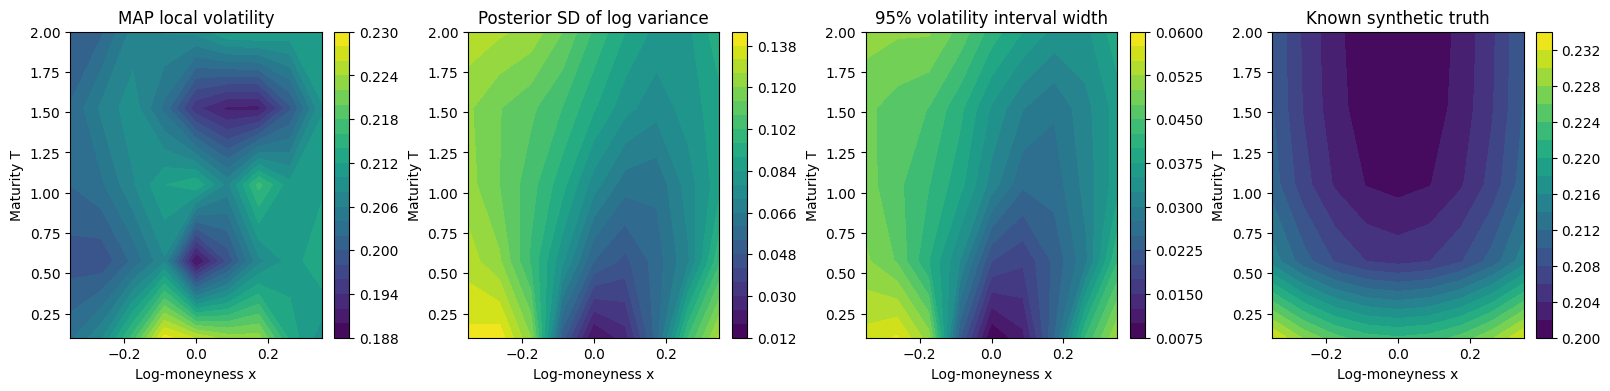

In [9]:
surface_shape = map_log_variance.shape

map_volatility = surface_summary[
    "volatility_median"
].to_numpy().reshape(
    surface_shape,
    order="C",
)
volatility_lower = surface_summary[
    "volatility_lower"
].to_numpy().reshape(
    surface_shape,
    order="C",
)
volatility_upper = surface_summary[
    "volatility_upper"
].to_numpy().reshape(
    surface_shape,
    order="C",
)
volatility_width = surface_summary[
    "volatility_interval_width"
].to_numpy().reshape(
    surface_shape,
    order="C",
)
sd_log_variance = surface_summary[
    "sd_log_variance"
].to_numpy().reshape(
    surface_shape,
    order="C",
)

x_mesh, maturity_mesh = np.meshgrid(
    calibration_x,
    calibration_T,
)
true_volatility = smile_surface(
    x_mesh,
    maturity_mesh,
)

truth_covered = (
    (true_volatility >= volatility_lower)
    & (true_volatility <= volatility_upper)
)

print(
    "Synthetic truth pointwise coverage:",
    f"{truth_covered.mean():.2%}",
)

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

for axis, surface, title in [
    (
        axes[0],
        map_volatility,
        "MAP local volatility",
    ),
    (
        axes[1],
        sd_log_variance,
        "Posterior SD of log variance",
    ),
    (
        axes[2],
        volatility_width,
        "95% volatility interval width",
    ),
    (
        axes[3],
        true_volatility,
        "Known synthetic truth",
    ),
]:
    contour = axis.contourf(
        calibration_x,
        calibration_T,
        surface,
        levels=20,
    )
    figure.colorbar(contour, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()


## 7. Predictive price uncertainty

Surface uncertainty propagates into latent model-price uncertainty:

$$
\Sigma_{\mathrm{price}}
\approx
J\Sigma_uJ^\top.
$$

For a future observed quote, its quote-noise variance is added:

$$
\operatorname{Var}(C_{\mathrm{obs},i}\mid y)
\approx
\left(
J\Sigma_uJ^\top
\right)_{ii}
+
s_i^2.
$$


In [10]:
noise_standard_deviation = synthetic_quotes[
    "noise_standard_deviation"
].to_numpy()

predictive_result = predictive_price_uncertainty(
    map_prices=map_prices_from_jacobian,
    jacobian=map_jacobian,
    posterior_covariance=posterior_covariance,
    noise_standard_deviation=noise_standard_deviation,
    credibility=0.95,
)

predictive_summary = synthetic_quotes[
    [
        "maturity",
        "log_moneyness",
        "strike",
        "true_call_price",
        "observed_call_price",
    ]
].copy()

predictive_summary["map_call_price"] = (
    map_prices_from_jacobian
)
predictive_summary["latent_price_sd"] = (
    predictive_result[
        "latent_standard_deviation"
    ]
)
predictive_summary["observed_predictive_sd"] = (
    predictive_result[
        "observed_standard_deviation"
    ]
)
predictive_summary["latent_lower"] = (
    predictive_result["latent_lower"]
)
predictive_summary["latent_upper"] = (
    predictive_result["latent_upper"]
)
predictive_summary["observed_lower"] = (
    predictive_result["observed_lower"]
)
predictive_summary["observed_upper"] = (
    predictive_result["observed_upper"]
)

latent_truth_coverage = np.mean(
    (
        predictive_summary["true_call_price"]
        >= predictive_summary["latent_lower"]
    )
    & (
        predictive_summary["true_call_price"]
        <= predictive_summary["latent_upper"]
    )
)

in_sample_observed_coverage = np.mean(
    (
        predictive_summary["observed_call_price"]
        >= predictive_summary["observed_lower"]
    )
    & (
        predictive_summary["observed_call_price"]
        <= predictive_summary["observed_upper"]
    )
)

print(
    "Synthetic clean-price pointwise coverage:",
    f"{latent_truth_coverage:.2%}",
)
print(
    "In-sample observed-price coverage:",
    f"{in_sample_observed_coverage:.2%}",
)


Synthetic clean-price pointwise coverage: 93.59%
In-sample observed-price coverage: 98.72%


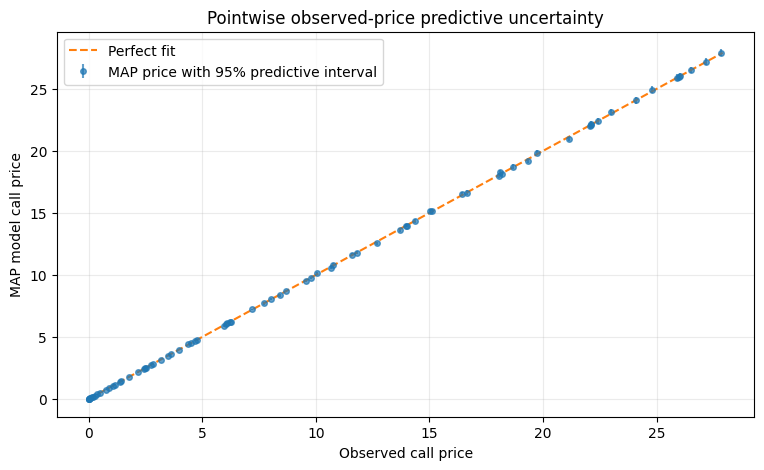

In [11]:
plot_order = np.argsort(
    synthetic_quotes["strike"].to_numpy()
)

plt.figure(figsize=(9, 5.0))
plt.errorbar(
    synthetic_quotes["observed_call_price"].to_numpy()[
        plot_order
    ],
    map_prices_from_jacobian[plot_order],
    yerr=(
        1.96
        * predictive_result[
            "observed_standard_deviation"
        ][plot_order]
    ),
    fmt="o",
    markersize=4,
    alpha=0.7,
    label="MAP price with 95% predictive interval",
)

minimum_price = min(
    synthetic_quotes["observed_call_price"].min(),
    map_prices_from_jacobian.min(),
)
maximum_price = max(
    synthetic_quotes["observed_call_price"].max(),
    map_prices_from_jacobian.max(),
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
    label="Perfect fit",
)
plt.xlabel("Observed call price")
plt.ylabel("MAP model call price")
plt.title("Pointwise observed-price predictive uncertainty")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Save Stage 9 outputs

The covariance is small enough to save directly because the current
calibration grid contains only \(45\) unknowns.


In [12]:
output_directory = (
    project_root
    / "outputs"
    / "stage_09"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

posterior_path = (
    output_directory
    / "laplace_posterior.npz"
)
surface_path = (
    output_directory
    / "surface_uncertainty.csv"
)
predictive_path = (
    output_directory
    / "predictive_uncertainty.csv"
)
history_path = (
    output_directory
    / "map_history.csv"
)

np.savez_compressed(
    posterior_path,
    calibration_maturities=calibration_T,
    calibration_x=calibration_x,
    reference_log_variance=reference_log_variance,
    map_log_variance=map_log_variance,
    map_volatility=map_volatility,
    selected_lambda=selected_lambda,
    regularization_matrix=(
        regularization_matrix.toarray()
    ),
    jacobian=map_jacobian,
    weights=weights,
    precision=laplace_result["precision"],
    covariance=posterior_covariance,
    correlation=laplace_result["correlation"],
    map_prices=map_prices_from_jacobian,
)

surface_summary.to_csv(
    surface_path,
    index=False,
)
predictive_summary.to_csv(
    predictive_path,
    index=False,
)
map_result["history"].to_csv(
    history_path,
    index=False,
)

print(posterior_path)
print(surface_path)
print(predictive_path)
print(history_path)


/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_09/laplace_posterior.npz
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_09/surface_uncertainty.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_09/predictive_uncertainty.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_09/map_history.csv


## Stage 9 result

The project now has a coherent uncertainty layer:

- the deterministic solution supplies the MAP estimate;
- the pricing Jacobian supplies local data sensitivity;
- the scaled regulariser supplies prior precision;
- the inverse precision gives posterior covariance;
- the covariance is propagated into local-volatility and price intervals.

This is exact for the locally linear Gaussian model and a Laplace
approximation for the nonlinear PDE model. It is deliberately simpler and more
transparent than full MCMC.
